# Homework 5 Kaggle Runner

Run this notebook on Kaggle with Internet enabled and a GPU accelerator selected.

In [1]:
!nvidia-smi

import torch

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("device:", torch.cuda.get_device_name(0))

Thu May  7 21:08:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%cd /kaggle/working
!git clone --depth 1 --branch main https://github.com/dobosipeter/advanced-image-processing-methods.git
%cd advanced-image-processing-methods

/kaggle/working
Cloning into 'advanced-image-processing-methods'...
remote: Enumerating objects: 111, done.
remote: Counting objects: 100% (111/111), done.
remote: Compressing objects: 100% (98/98), done.
remote: Total 111 (delta 5), reused 93 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (111/111), 119.02 MiB | 47.63 MiB/s, done.
Resolving deltas: 100% (5/5), done.
/kaggle/working/advanced-image-processing-methods


In [3]:
!pip install -e homework_5

Obtaining file:///kaggle/working/advanced-image-processing-methods/homework_5
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for mw79on_submission_hw5 (pyproject.toml) ... done
  Created wheel for mw79on_submission_hw5: filename=mw79on_submission_hw5-1.0.0-0.editable-py3-none-any.whl size=3867 sha256=216b87501c654d36c950d5d5d8656a2e521d5feb4ab0aefb0e8f0ab96b25d76b
  Stored in directory: /tmp/pip-ephem-wheel-cache-1g5pbf2w/wheels/8c/2c/e5/28988c8f07de6b071661092daa19d3c1905cf122b38d5168fa
Successfully built mw79on_submission_hw5


In [4]:
!python homework_5/src/mw79on_submission_hw5/main.py

2026-05-07 21:10:20,932 - __main__ - INFO - Project root : /kaggle/working/advanced-image-processing-methods/homework_5
2026-05-07 21:10:20,933 - __main__ - INFO - Data root    : /kaggle/working/advanced-image-processing-methods/homework_5/data
2026-05-07 21:10:20,933 - __main__ - INFO - Output dir   : /kaggle/working/advanced-image-processing-methods/homework_5/output
2026-05-07 21:10:20,933 - __main__ - INFO - Runtime config — device=cuda batch_size=32 num_workers=2 pin_memory=True image_size=224 epochs=30 patience=5 lr=1.0e-04 wd=1.0e-04
100%|████████████████████████████████████████| 625M/625M [00:17<00:00, 36.4MB/s]
2026-05-07 21:10:45,279 - __main__ - INFO - DTD partition=1 — train: 1880  val: 1880  test: 1880  classes: 47
2026-05-07 21:10:45,279 - __main__ - INFO - Subtask 1 complete.
Downloading: "https://download.pytorch.org/models/maxvit_t-bc5ab103.pth" to /root/.cache/torch/hub/checkpoints/maxvit_t-bc5ab103.pth
100%|█████████████████████████████████████████| 119M/119M [00:00<

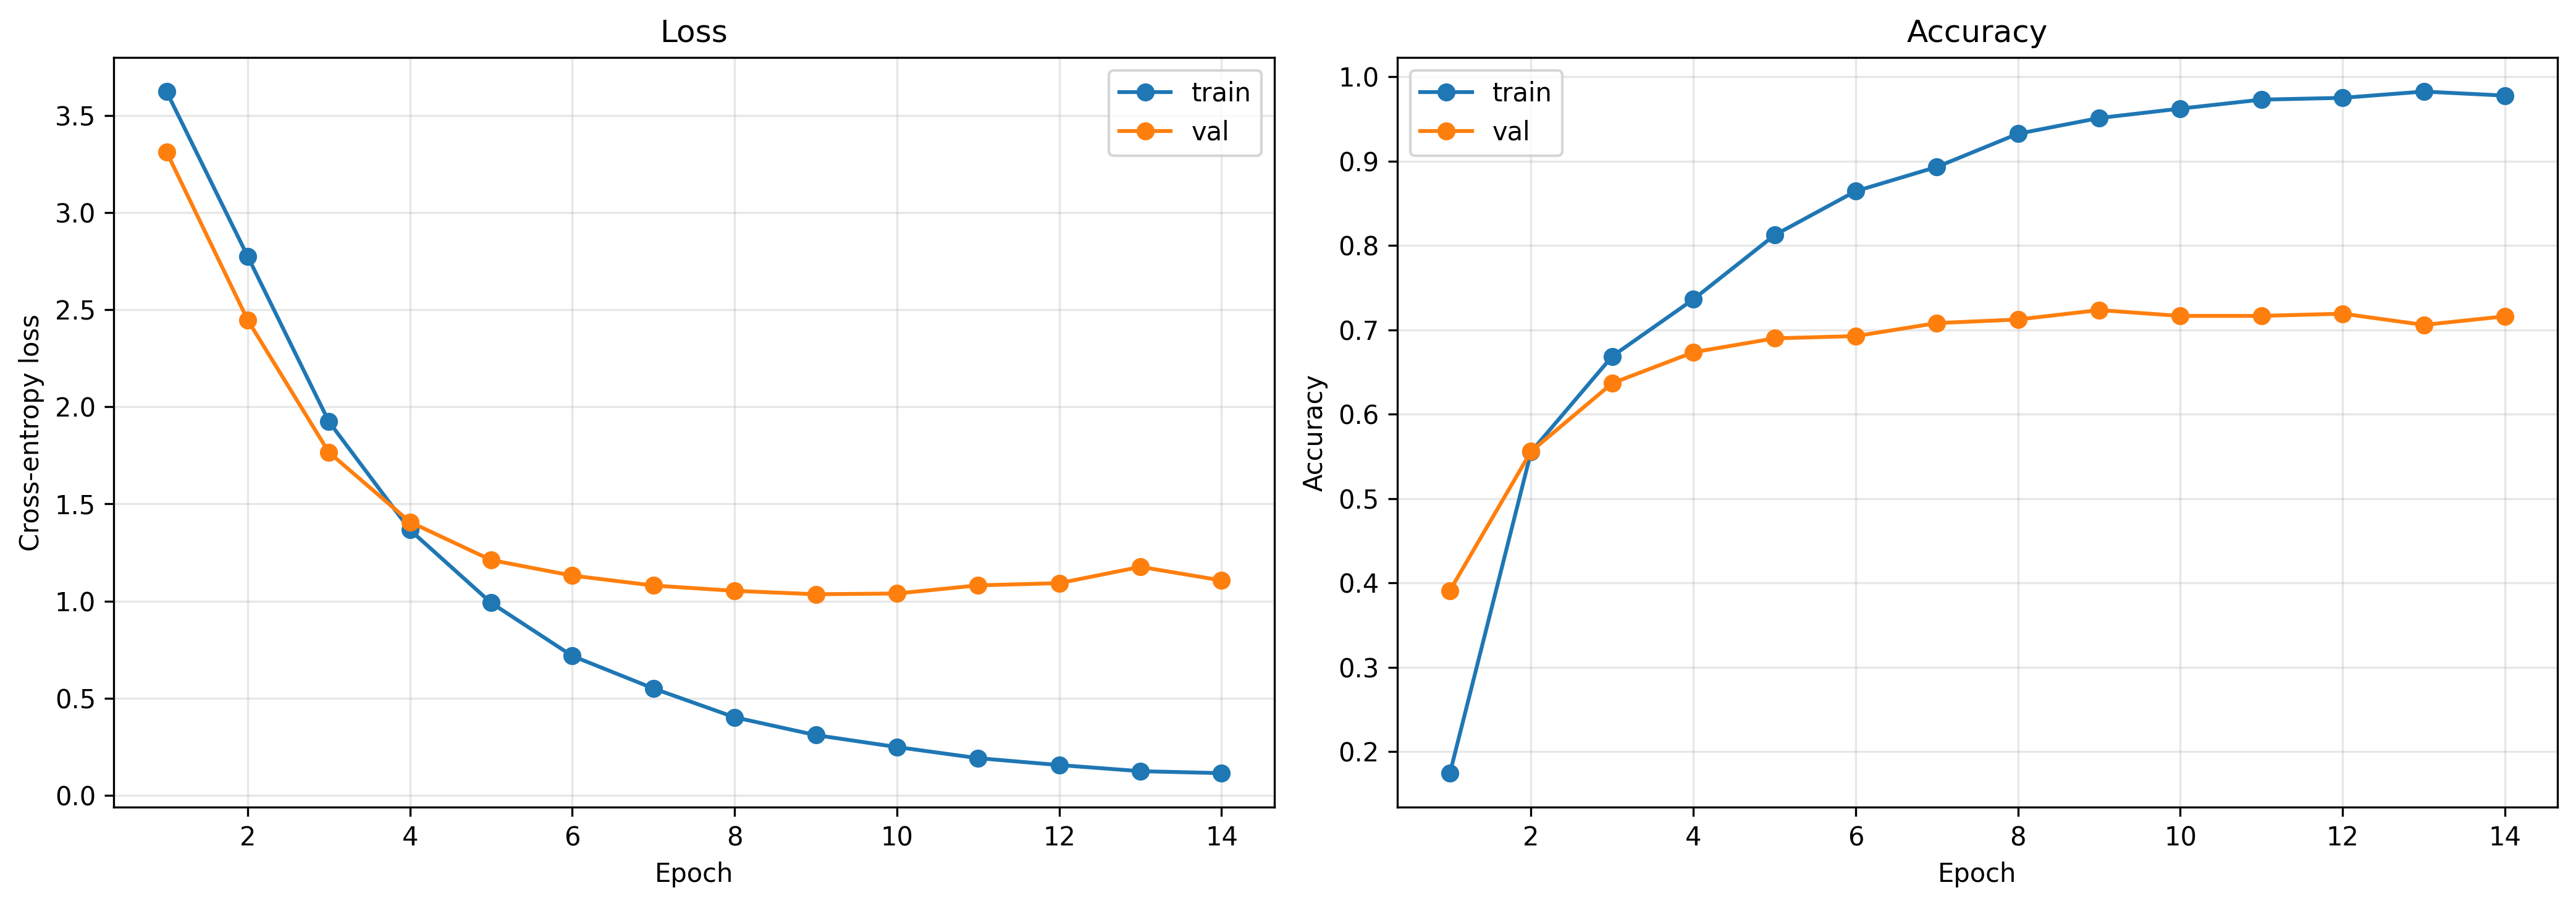

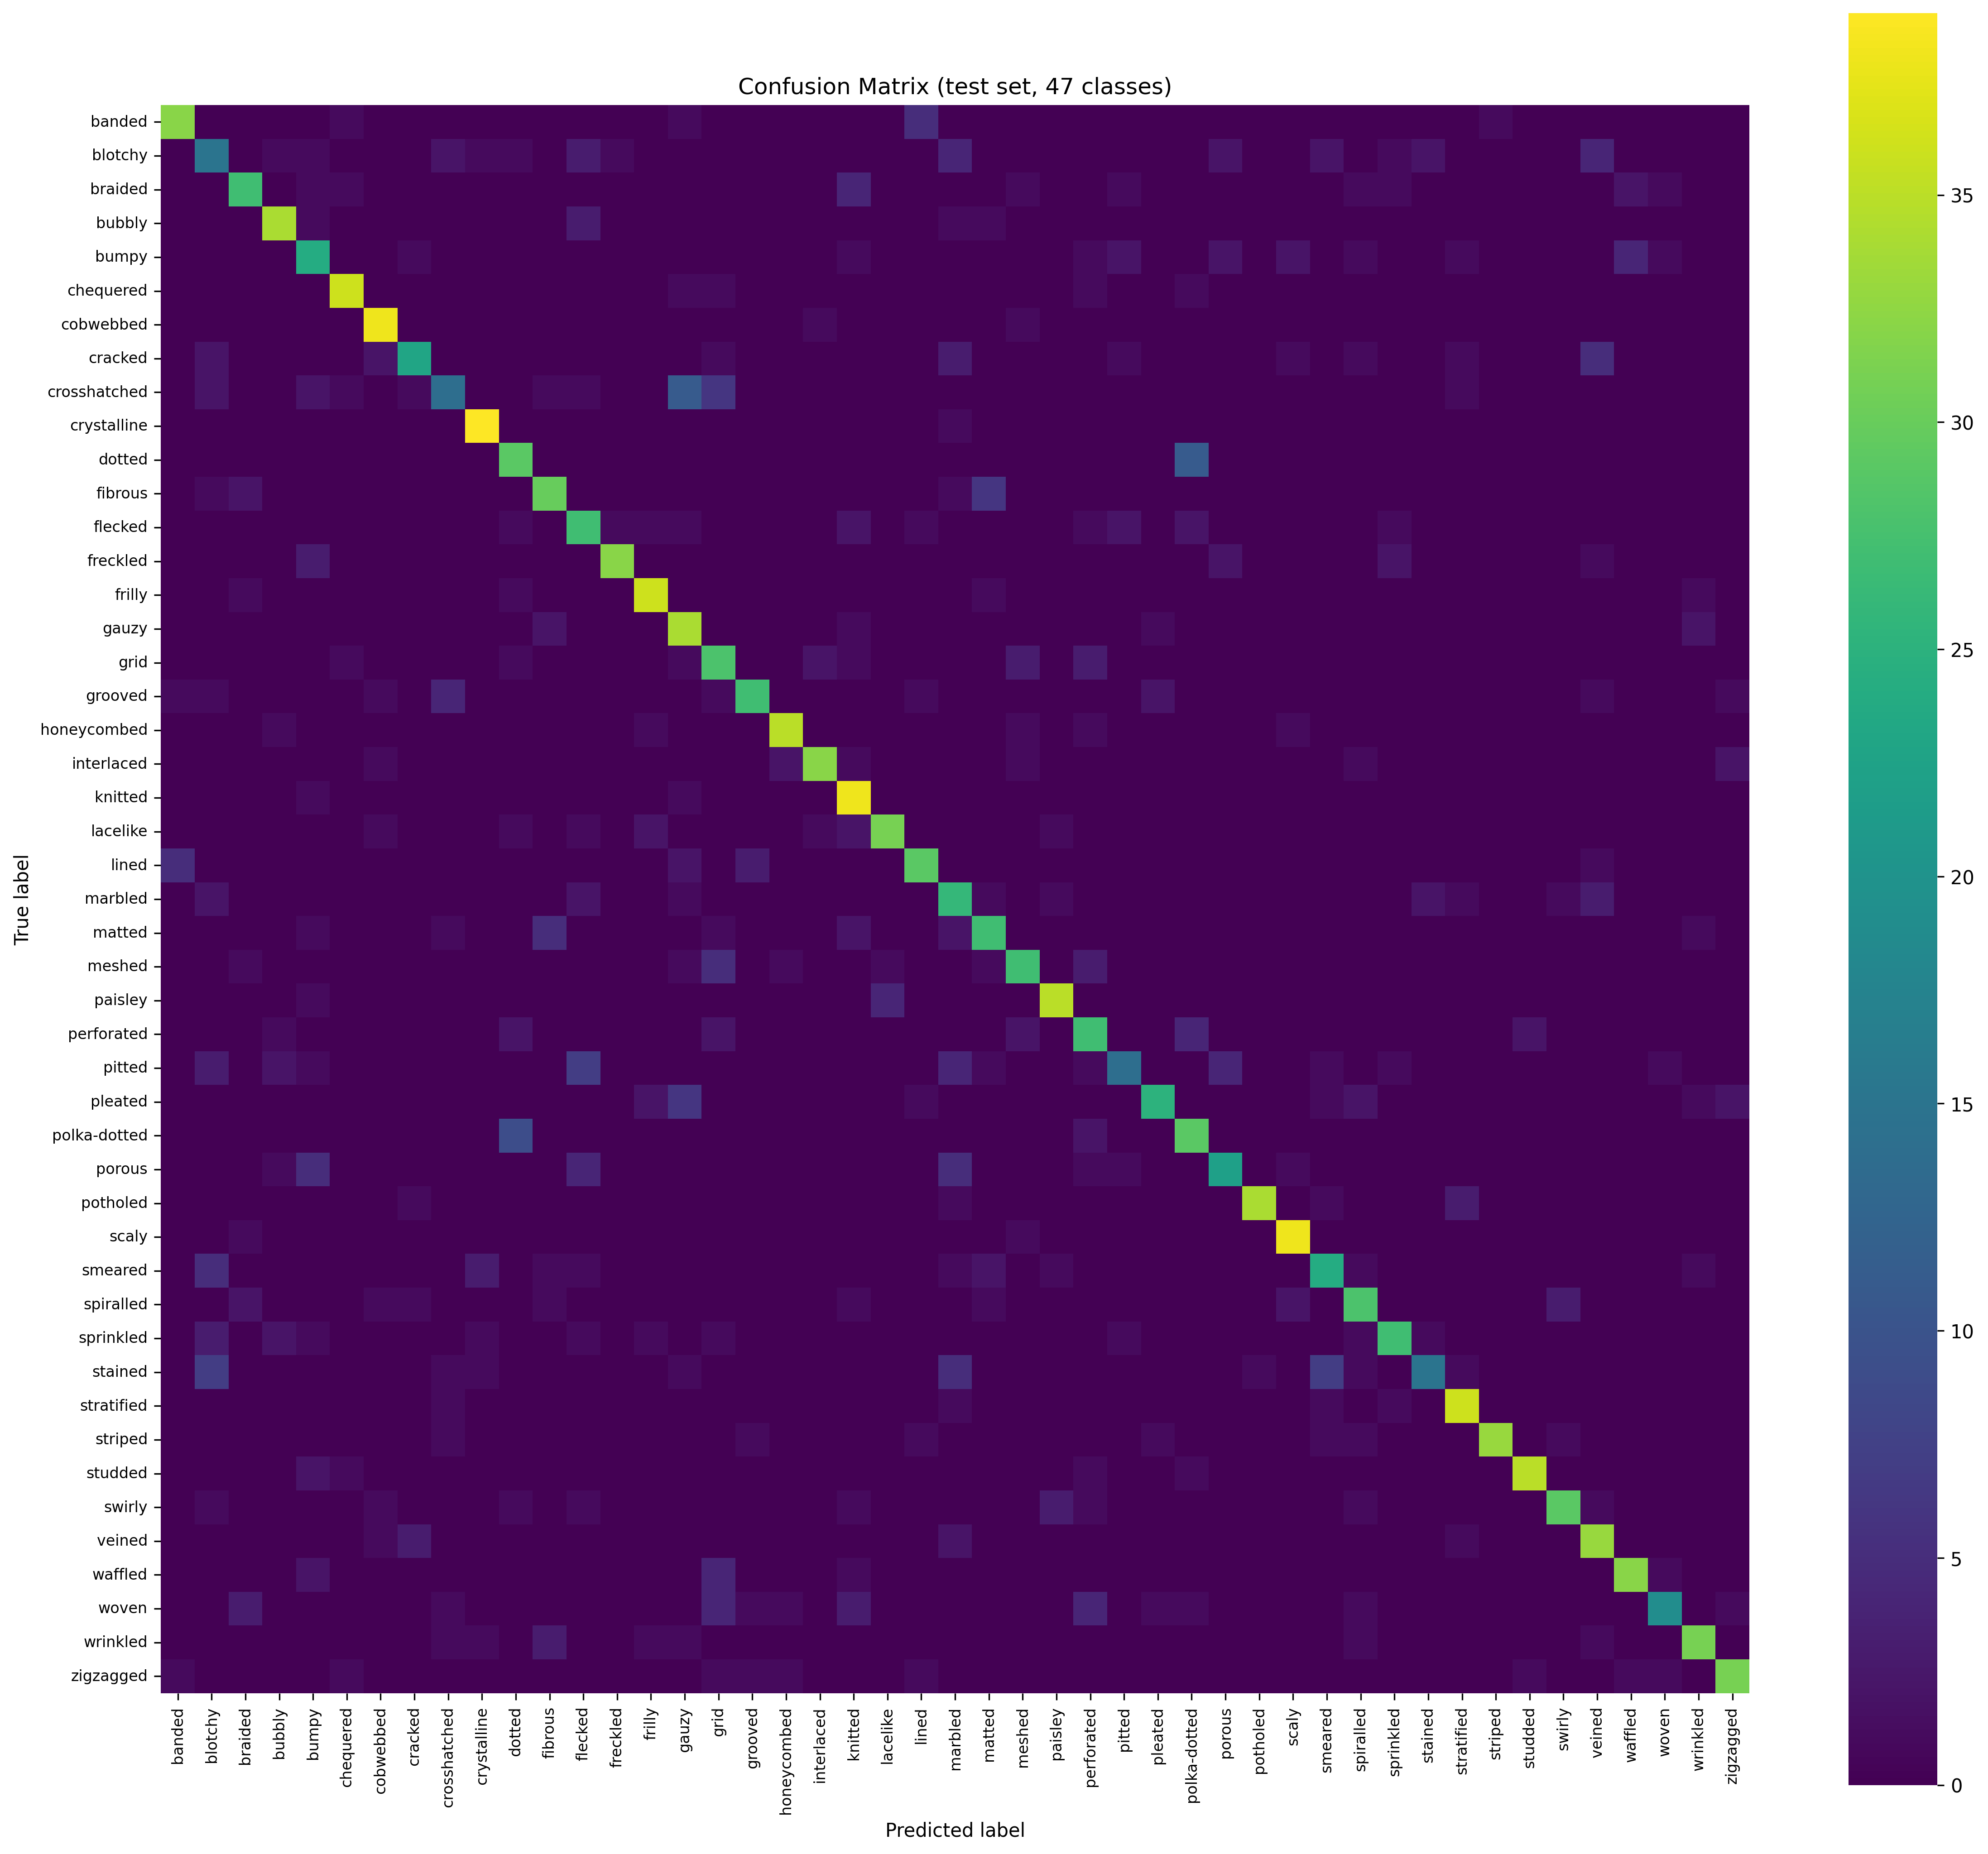

Staged outputs:
/kaggle/working/training_curves.png 0.22 MiB
/kaggle/working/confusion_matrix.png 0.41 MiB
/kaggle/working/best_model.pt 116.92 MiB


In [5]:
import shutil
from pathlib import Path
from IPython.display import Image, display

src = Path("homework_5/output")
dst = Path("/kaggle/working")

for name in ("training_curves.png", "confusion_matrix.png"):
    output_path = src / name
    staged_path = dst / name
    shutil.copy(output_path, staged_path)
    display(Image(filename=str(staged_path)))

shutil.copy(src / "best_model.pt", dst / "best_model.pt")

print("Staged outputs:")
for name in ("training_curves.png", "confusion_matrix.png", "best_model.pt"):
    path = dst / name
    print(path, f"{path.stat().st_size / (1024 * 1024):.2f} MiB")